# Prepare FINDR dataset from pyNeuroDAP outputs

This notebook builds a `.npz` dataset compatible with FINDR, using outputs produced by `analyze_sessions_forPlexon.py` in this repo. It follows the data format described in the FINDR README: `spikes`, `externalinputs`, `lengths`, `times`.

Reference: Brody-Lab/findr (`https://github.com/Brody-Lab/findr`).


In [45]:
from pathlib import Path
import os
import numpy as np
import scipy.io as sio

# Local pyNeuroDAP helpers
import pyNeuroDAP as ndap
os.chdir("/Users/shunli/Projects/pyNeuroDAP")

# Paths: point to a specific analyzed session directory
# Example (adjust to your session):
MAT_PATH = Path('Data/20250622-Data-InsCtx/20250618_M346_4W50_g0_ccm.mat')
SESSION_DIR = MAT_PATH.parent
session_id = os.path.basename(MAT_PATH)

# Output .npz path for FINDR
FINDR_NPZ = SESSION_DIR / f'{session_id.replace(".mat", "")}_findr_dataset.npz'

print('Mat file:', MAT_PATH)
print('Output npz:', FINDR_NPZ)


Mat file: Data/20250622-Data-InsCtx/20250618_M346_4W50_g0_ccm.mat
Output npz: Data/20250622-Data-InsCtx/20250618_M346_4W50_g0_ccm_findr_dataset.npz


In [2]:
# Load .mat file and extract data
session_mat = sio.loadmat(str(MAT_PATH))

# Extract mat file data
params = ndap.convert_params_from_mat(session_mat)
spikes = ndap.convert_spikes_from_mat(params, user='shijia')
behaviors = ndap.convert_behaviors_from_mat(session_mat, user='shijia')

print('behaviors keys:', list(behaviors.keys()))
print('trial_start_times conditions:', list(behaviors['trial_start_times'].keys()))
print('licks conditions:', list(behaviors['licks'].keys()))


behaviors keys: ['trial_start_times', 'licks']
trial_start_times conditions: ['reward_control', 'omission_control', 'miss_control']
licks conditions: ['reward_control', 'omission_control']


In [31]:
# Define parameters for alignment
bin_size = 25           # in ms
time_range = (-3, 5)    # in sec

# Align spikes to trial start events
from tqdm import tqdm

print('Aligning spikes to trial start events...')
aligned_trial_start = {}
for cond, times in tqdm(behaviors['trial_start_times'].items(), desc="Aligning to trial starts", leave=True):
    aligned_trial_start[cond] = ndap.get_spikes(spikes, np.array(times), time_range, bin_size_ms=bin_size,
                                                subtract_baseline=True, same_system=False, params=params)

print('Aligned conditions:', list(aligned_trial_start.keys()))
for cond in aligned_trial_start.keys():
    rate = aligned_trial_start[cond]['rate']  # numpy array (units, trials, timebins)
    print(cond, 'rate shape:', rate.shape)


Aligning spikes to trial start events...


Aligning to trial starts: 100%|██████████| 3/3 [00:02<00:00,  1.20it/s]

Aligned conditions: ['reward_control', 'omission_control', 'miss_control']
reward_control rate shape: (782, 149, 320)
omission_control rate shape: (782, 179, 320)
miss_control rate shape: (782, 3, 320)


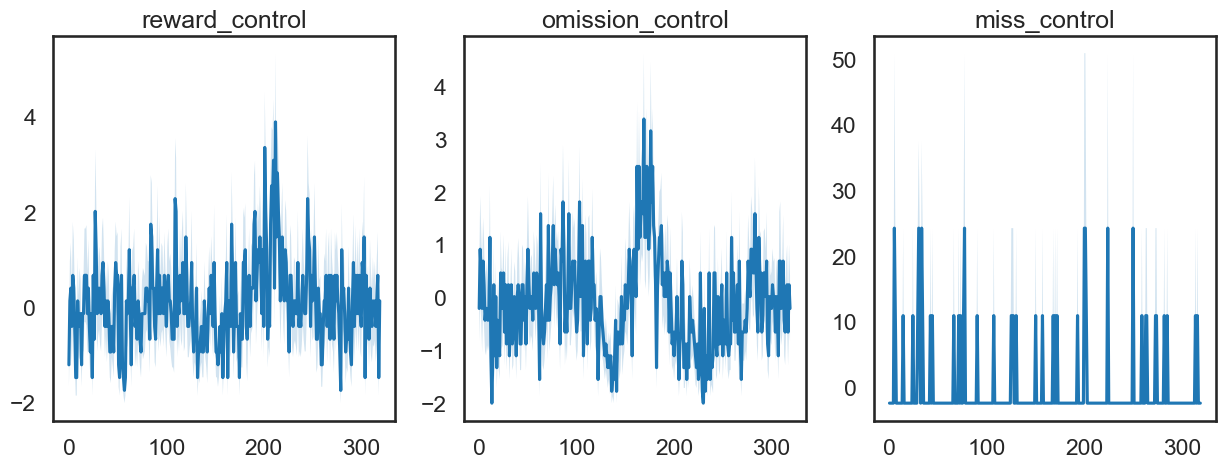

In [32]:
# Plot example aligned spikes for each condition
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1,len(aligned_trial_start), figsize=(15, 5), sharex=True)

unit_id = 109
for i, (cond, aligned_data) in enumerate(aligned_trial_start.items()):
    rate = aligned_data['rate']
    ndap.plot_sem(rate[unit_id], ax=axs[i])
    axs[i].set_title(cond)
plt.show()

## Prepare FINDR dataset

In [33]:
# Build FINDR arrays
# FINDR expects:
# - spikes: (num_trials, max_T, num_neurons) of binned spike counts
# - externalinputs: (num_trials, max_T, input_dim)
# - lengths: (num_trials,) lengths per trial
# - times: (num_trials,) onset timestamp per trial

# External inputs: 2 channels
# Channel 0: trial start event (1 at time 0, which is the alignment point)
# Channel 1: all lick events (1 at the time of each lick relative to trial start)
input_dim = 2

# Get time range parameters
tr_start_s, tr_end_s = time_range
bin_size_s = bin_size / 1000.0  # convert ms to seconds
num_bins = int((tr_end_s - tr_start_s) * 1000 / bin_size)

# Helper function to convert time (in seconds) to bin index
def sec_to_bin_index(t_sec):
    """Convert time in seconds relative to trial start to bin index."""
    return int(np.clip(np.floor((t_sec - tr_start_s) / bin_size_s), 0, num_bins - 1))

# Gather per-trial tensors
trial_spikes = []
trial_inputs = []
trial_lengths = []
trial_onsets = []

use_conditions = list(aligned_trial_start.keys())  # Use all conditions

for cond in use_conditions:
    aligned_data = aligned_trial_start[cond]
    rate = aligned_data['rate']  # shape: (units, trials, timebins)
    U, T, B = rate.shape
    
    # Get trial start times and all lick times for this condition
    trial_start_vec = behaviors['trial_start_times'][cond]
    licks_data = behaviors['licks'].get(cond, None)  # 2D array: (num_licks, num_trials)
    
    for t in range(T):
        # Extract spike data for this trial
        x = np.array(rate[:, t, :], dtype=np.float32)  # (U, B)
        x = np.transpose(x, (1, 0))                    # (B, U)
        trial_spikes.append(x)
        
        # Build time-varying inputs per-bin
        B_local = x.shape[0]
        u = np.zeros((B_local, input_dim), dtype=np.float32)
        
        # Channel 0: Trial start event (at time 0, which is bin corresponding to tr_start_s offset)
        # Since we're aligned to trial start, trial start is at time 0 relative to alignment
        trial_start_bin = sec_to_bin_index(0.0)
        if 0 <= trial_start_bin < B_local:
            u[trial_start_bin, 0] = 1.0
        
        # Channel 1: All lick events
        if licks_data is not None and len(trial_start_vec) > t:
            trial_start_time_abs = trial_start_vec[t]
            # Iterate through all lick rows (each row is a different lick number)
            num_lick_types = licks_data.shape[0] if len(licks_data.shape) > 1 else 1
            for lick_idx in range(num_lick_types):
                if len(licks_data.shape) > 1:
                    lick_times = licks_data[lick_idx, :]
                else:
                    lick_times = licks_data
                
                if len(lick_times) > t:
                    lick_time_abs = lick_times[t]
                    # Skip if lick time is NaN or invalid
                    if not np.isnan(lick_time_abs) and lick_time_abs > 0:
                        # Convert to relative time (lick time - trial start time)
                        lick_time_rel = lick_time_abs - trial_start_time_abs
                        lick_bin = sec_to_bin_index(lick_time_rel)
                        if 0 <= lick_bin < B_local:
                            u[lick_bin, 1] = 1.0
        
        trial_inputs.append(u)
        trial_lengths.append(B_local)
        
        # Trial onset time (absolute time)
        if len(trial_start_vec) > t:
            trial_onsets.append(float(trial_start_vec[t]))
        else:
            trial_onsets.append(np.nan)

# Pad trials to max_T
max_T = max(trial_lengths) if trial_lengths else 0
num_trials = len(trial_spikes)
num_neurons = trial_spikes[0].shape[1] if num_trials > 0 else 0

spikes_arr = np.zeros((num_trials, max_T, num_neurons), dtype=np.float32)
inputs_arr = np.zeros((num_trials, max_T, input_dim), dtype=np.float32)
lengths_arr = np.array(trial_lengths, dtype=np.int32)
times_arr = np.array(trial_onsets, dtype=np.float64)

for i, (x, u) in enumerate(zip(trial_spikes, trial_inputs)):
    L = x.shape[0]
    spikes_arr[i, :L, :] = x
    inputs_arr[i, :L, :] = u

print('spikes:', spikes_arr.shape)
print('externalinputs:', inputs_arr.shape)
print('lengths:', lengths_arr.shape)
print('times:', times_arr.shape)


spikes: (331, 320, 782)
externalinputs: (331, 320, 2)
lengths: (331,)
times: (331,)


In [34]:
# Save .npz for FINDR
np.savez_compressed(
    FINDR_NPZ,
    spikes=spikes_arr,
    externalinputs=inputs_arr,
    lengths=lengths_arr,
    times=times_arr,
)
print('Saved:', FINDR_NPZ)


Saved: Data/20250622 Data (InsCtx Chronic)/20250618_M346_4W50_g0_ccm_findr_dataset.npz


## Run FINDR training

In [76]:
import os
from datetime import datetime

# Assumptions:
# FINDR_NPZ: path to saved npz file, e.g. "/Users/shunli/Projects/session_folder/my_dataset.npz"
# Change "findr_folder_server" to the relevant findr folder in the server you intend to use


npz_basename = os.path.basename(FINDR_NPZ)
session_folder = os.path.basename(os.path.dirname(FINDR_NPZ))  # uses the directory containing the .npz as session name
findr_dataset_local = os.path.join("/Users/shunli/Projects/pyNeuroDAP/Data/", session_folder,npz_basename)

# Setup results folder in server
findr_folder_server = "/n/holylabs/LABS/bsabatini_lab/Users/shunnnli/findr/datasets"
ssh = "shunnnli@login.rc.fas.harvard.edu:"
date_str = datetime.now().strftime("%Y%m%d")
results_folder_name = f"findr-results-{date_str}"
server_session_path = os.path.join(findr_folder_server, session_folder)
server_session_path_ssh = ssh + server_session_path
server_results_path = os.path.join(server_session_path, results_folder_name)

# command: copy .npz file to server session folder
rsync_cmd = (
    f"rsync -av --progress '{findr_dataset_local}' '{server_session_path_ssh}/'"
)
makedir_cmd = f"mkdir -p '{server_results_path}'"
datafilepath = os.path.join(server_session_path, npz_basename)
analysispath = server_results_path
run_findr_cmd = (
    f"python main.py --datapath='{datafilepath}' --workdir='{analysispath}'"
)

# Server (on cluster) command: create results folder for analysis output
print("\n=== 1. ON LOCAL, run this command to copy your npz dataset to the server ===")
print(rsync_cmd)
print("\n=== 2. ON SERVER, run this command to create the analysis folder ===")
print(makedir_cmd)
print("\n=== 3. ON SERVER, run this command to launch FINDR training ===")
print(run_findr_cmd)



=== 1. ON LOCAL, run this command to copy your npz dataset to the server ===
rsync -av --progress '/Users/shunli/Projects/pyNeuroDAP/Data/20250622-Data-InsCtx/20250618_M346_4W50_g0_ccm_findr_dataset.npz' 'shunnnli@login.rc.fas.harvard.edu:/n/holylabs/LABS/bsabatini_lab/Users/shunnnli/findr/datasets/20250622-Data-InsCtx/'

=== 2. ON SERVER, run this command to create the analysis folder ===
mkdir -p '/n/holylabs/LABS/bsabatini_lab/Users/shunnnli/findr/datasets/20250622-Data-InsCtx/findr-results-20251106'

=== 3. ON SERVER, run this command to launch FINDR training ===
python main.py --datapath='/n/holylabs/LABS/bsabatini_lab/Users/shunnnli/findr/datasets/20250622-Data-InsCtx/20250618_M346_4W50_g0_ccm_findr_dataset.npz' --workdir='/n/holylabs/LABS/bsabatini_lab/Users/shunnnli/findr/datasets/20250622-Data-InsCtx/findr-results-20251106'
